<div align="center">
  <h3><b>ESCUELA POLITÉCNICA NACIONAL</b></h3>
  <h3><b>FACULTAD DE SISTEMAS</b></h3>
  <h3><b>INGENIERÍA EN CIENCIAS DE LA COMPUTACIÓN</b></h3>
  <h3><b>RECUPERACIÓN DE LA INFORMACIÓN</b></h3>
</div>

---
**Nombre**   Mark Hernández       
**Fecha**    27/05/26  
**Docente**  Iván Carrera

#### Librerías:

Cargamos las librerías del modelo de embeddings

In [1]:
%pip install -q sentence-transformers

Note: you may need to restart the kernel to use updated packages.


Cargamos las librerías necesarias:

In [45]:
import kagglehub
import os
import pandas as pd
import re
import unicodedata
from sentence_transformers import SentenceTransformer
from tqdm import tqdm
import numpy as np
import pickle
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

## Examen Primer Bimestre 

#### 1. Carga del Corpus

Primero realizamos la carga del corpus para el dataset **Rotten Tomatoes movies and critic reviews dataset** desde Kagglehub.

In [3]:
# Download latest version
path = kagglehub.dataset_download("stefanoleone992/rotten-tomatoes-movies-and-critic-reviews-dataset")

print("Path to dataset files:", path)

print("Archivos en la carpetea descargada:")
for f in os.listdir(path):
    print(f)

Path to dataset files: C:\Users\mark_\.cache\kagglehub\datasets\stefanoleone992\rotten-tomatoes-movies-and-critic-reviews-dataset\versions\1
Archivos en la carpetea descargada:
rotten_tomatoes_critic_reviews.csv
rotten_tomatoes_movies.csv


Antes de escoger con que archivo trabajar revisamos que campos posee cada uno.

In [4]:
# Revisamos los campos de cada CSV
for f in os.listdir(path):
    filepath = os.path.join(path, f)
    df = pd.read_csv(filepath, nrows=0)  # Leemos el header sin cargar datos.
    print(f"\n📄 {f}")
    print(f"   Campos ({len(df.columns)}):")
    for col in df.columns:
        print(f"     - {col}")


📄 rotten_tomatoes_critic_reviews.csv
   Campos (8):
     - rotten_tomatoes_link
     - critic_name
     - top_critic
     - publisher_name
     - review_type
     - review_score
     - review_date
     - review_content

📄 rotten_tomatoes_movies.csv
   Campos (22):
     - rotten_tomatoes_link
     - movie_title
     - movie_info
     - critics_consensus
     - content_rating
     - genres
     - directors
     - authors
     - actors
     - original_release_date
     - streaming_release_date
     - runtime
     - production_company
     - tomatometer_status
     - tomatometer_rating
     - tomatometer_count
     - audience_status
     - audience_rating
     - audience_count
     - tomatometer_top_critics_count
     - tomatometer_fresh_critics_count
     - tomatometer_rotten_critics_count


Luego de revisar los campos, podemos concluir que para este examen se hará uso de ambos archivos. Esta decisión se la toma a partir de analizar los requerimientos para la visualización de las consultas, en la cual se nos pide incluir el título de la película (movie_title) el cual está en el archivo **rotten_tomatoes_movies.csv** y el texto de la crítica (review_content) que se encuentra en el archivo **rotten_tomatoes_critic_reviews.csv**

In [5]:
# --- 1. CARGA Y UNIÓN DE DATASETS ---
print("Cargando datasets...")
movies_path = f"{path}/rotten_tomatoes_movies.csv"
reviews_path = f"{path}/rotten_tomatoes_critic_reviews.csv"

movies_df = pd.read_csv(movies_path)
reviews_df = pd.read_csv(reviews_path)

# Unimos utilizando 'rotten_tomatoes_link' (realizamos un inner join para conservar solo reseñas con película asociada)
print("Uniendo datasets y seleccionando campos...")
df_merged = pd.merge(reviews_df, movies_df[['rotten_tomatoes_link', 'movie_title', 'genres']], 
                     on='rotten_tomatoes_link', 
                     how='inner')

# Seleccionamos los campos necesarios: Título, Género, Texto de la reseña y Nombre del crítico.
# Eliminamos las filas sin texto con dropna() y creamos Document ID en lugar del link.
df = df_merged[['movie_title','genres','review_content','critic_name']].dropna(subset=['review_content']).reset_index(drop=True)
df.insert(0, 'Document ID', df.index.map(lambda i: f"Movie_{i}"))

df.head(5)

Cargando datasets...
Uniendo datasets y seleccionando campos...


,Document ID,movie_title,genres,review_content,critic_name
0,Movie_0,Percy Jackson & the Olympians: The Lightning T...,"Action & Adventure, Comedy, Drama, Science Fic...",A fantasy adventure that fuses Greek mythology...,Andrew L. Urban
1,Movie_1,Percy Jackson & the Olympians: The Lightning T...,"Action & Adventure, Comedy, Drama, Science Fic...","Uma Thurman as Medusa, the gorgon with a coiff...",Louise Keller
2,Movie_2,Percy Jackson & the Olympians: The Lightning T...,"Action & Adventure, Comedy, Drama, Science Fic...",With a top-notch cast and dazzling special eff...,NaN
3,Movie_3,Percy Jackson & the Olympians: The Lightning T...,"Action & Adventure, Comedy, Drama, Science Fic...",Whether audiences will get behind The Lightnin...,Ben McEachen
4,Movie_4,Percy Jackson & the Olympians: The Lightning T...,"Action & Adventure, Comedy, Drama, Science Fic...",What's really lacking in The Lightning Thief i...,Ethan Alter


Antes de proceder al preprocesamiento verificamos el tamaño de nuestro dataset.

In [6]:
print(f"Tamaño del corpus: {len(df)}")

Tamaño del corpus: 1064109


Puesto que el tamaño del corpus posee más de 1 millón de documentos, tomaremos una muestra representativa de 20000 documentos.

In [10]:
df = df.sample(n=20000, random_state=42).reset_index(drop=True)
df.head()

,Document ID,movie_title,genres,review_content,critic_name,processed_review
0,Movie_448868,Julie & Julia,"Comedy, Drama",Julie & Julia was directed by Nora Ephron with...,Joe Williams,julie julia was directed by nora ephron with a...
1,Movie_681960,The Road to Love,"Art House & International, Drama","Doesn't add much to the coming-out genre, as i...",Dave Kehr,doesnt add much to the comingout genre as it h...
2,Movie_66002,The Boys Are Back,Drama,Hicks's hand with these relationships is more ...,Tim Robey,hickss hand with these relationships is more t...
3,Movie_314166,Fat Man and Little Boy,Drama,"An interesting historical drama, but lacks the...",Bob Bloom,an interesting historical drama but lacks the ...
4,Movie_357075,Gone Girl,"Drama, Mystery & Suspense","Unfortunately, and more to the point than the ...",Anna Storm,unfortunately and more to the point than the f...


#### 2. Preprocesamiento

Primero creamos la función de limpieza solicitada con conversión de minúsculas, eliminación de signos de puntuación y eliminación de espacios redundantes. Además, se incorporarán 2 técnicas: eliminación de stopwords y normalización de caracteres.

In [11]:
def preprocess_text(texto):
        """
        Convierte a minúsculas, elimina signos de puntuación, elimina espacios redundantes, y aplica la normalización de caracteres.
        """
        if not isinstance(texto, str):
            return []
        
        # 1. Normalización de caracteres (eliminar acentos/diacríticos y pasar a ASCII)
        text = unicodedata.normalize('NFKD', texto).encode('ASCII', 'ignore').decode('utf-8')
        # 2. Conversión a minúsculas
        text = text.lower()
        # 3. Eliminación de signos de puntuación
        text = re.sub(r'[^\w\s]', '', text)
        # 4. Eliminación de stopwords y 5. Eliminación de espacios redundantes
        words = text.split()
        
        return ' '.join(words)

Aplicamos nuestra función de preprocesamiento a la columna *content_review* en el dataframe y creamos una nueva columna llamada *processed_review*.

In [12]:
print("Iniciando preprocesamiento...")

# Aplicar la función al contenido de las reseñas
df['processed_review'] = df['review_content'].apply(preprocess_text)
# Mostrar una muestra para verificar los cambios
df[['review_content', 'processed_review']].head()

Iniciando preprocesamiento...


,review_content,processed_review
0,Julie & Julia was directed by Nora Ephron with...,julie julia was directed by nora ephron with a...
1,"Doesn't add much to the coming-out genre, as i...",doesnt add much to the comingout genre as it h...
2,Hicks's hand with these relationships is more ...,hickss hand with these relationships is more t...
3,"An interesting historical drama, but lacks the...",an interesting historical drama but lacks the ...
4,"Unfortunately, and more to the point than the ...",unfortunately and more to the point than the f...


#### 3. Generación de embeddings

Para la generación del embedding usaremos el modelo *all-MiniLM-L6-v2*. Este modelo genera vectores de 384 dimensiones y, además, es rápido y precios para NLP en inglés.

In [13]:
# Inicializamos tqdm para pandas (esto nos permite usar progress_apply)
tqdm.pandas()

print("Cargando el modelo de Sentence Transformers...")
model = SentenceTransformer('all-MiniLM-L6-v2')

# Ruta para guardar los embeddings y no tener que recalcularlos si se reinicia el kernel
embeddings_file = "review_embeddings.pkl"

if os.path.exists(embeddings_file):
    print("Cargando embeddings previamente guardados...")
    with open(embeddings_file, "rb") as f:
        document_embeddings = pickle.load(f)
    print(f"Se cargaron {len(document_embeddings)} embeddings.")
else:
    print("Generando embeddings...")
    
    # Convertimos la columna de texto preprocesado a una lista
    sentences = df['processed_review'].tolist()
    
    # Generamos los embeddings. show_progress_bar=True es útil para monitorear el avance.
    document_embeddings = model.encode(sentences, show_progress_bar=True, batch_size=32)
    
    # Guardamos los embeddings en disco para futuras ejecuciones
    with open(embeddings_file, "wb") as f:
        pickle.dump(document_embeddings, f)
    print("Embeddings generados y guardados con éxito.")

Cargando el modelo de Sentence Transformers...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7689.81it/s]


Generando embeddings (esto puede tomar varios minutos dependiendo del tamaño del corpus)...


Batches: 100%|██████████| 625/625 [02:41<00:00,  3.86it/s]


Embeddings generados y guardados con éxito.
Forma de la matriz de embeddings: (20000, 384)


Verificamos que los embeddings se han creado corrctamente. Para ello vamos a inspeccionar las dimensiones de la matriz resultante, el tipo de dato y dar un vistazo a los valores numéricos del primer vector junto con su texto correspondiente.

In [14]:
# --- INSPECCIÓN DE LOS EMBEDDINGS ---
print("Verificando la creación de los embeddings...\n")

# Debería mostrarnos (N, 384) donde N es el número de reseñas procesadas (en este  caso N=20000)
print(f"Dimensiones de la matriz de embeddings: {document_embeddings.shape}")
print(f"Número de documentos: {document_embeddings.shape[0]}")
print(f"Dimensiones por documento: {document_embeddings.shape[1]}\n")

# 2. Verificación del tipo de dato
print(f"Tipo de dato de los embeddings: {document_embeddings.dtype}\n")

# 3. Mostramos el primer documento y una muestra de su vector
print("Ejemplo del primer documento:")
print(f"Texto original: {df['review_content'].iloc[0]}")
print(f"Texto procesado: {df['processed_review'].iloc[0]}\n")

print("Muestra de los primeros 10 valores de su vector embedding:")
# Imprimimos solo los primeros 10 valores
print(document_embeddings[0][:10])

Verificando la creación de los embeddings...

Dimensiones de la matriz de embeddings: (20000, 384)
Número de documentos: 20000
Dimensiones por documento: 384

Tipo de dato de los embeddings: float32

Ejemplo del primer documento:
Texto original: Julie & Julia was directed by Nora Ephron with a light touch that will satisfy an eager audience of female foodies.
Texto procesado: julie julia was directed by nora ephron with a light touch that will satisfy an eager audience of female foodies

Muestra de los primeros 10 valores de su vector embedding:
[-0.03654959 -0.09860607 -0.03229444  0.01009429 -0.02108979  0.05763175
  0.04786137  0.04821831  0.02960138 -0.03150341]


#### 4. Implementación de una función de búsqueda con similitud coseno

In [31]:
def buscar_por_similitud(query, df_corpus, modelo_embeddings, embeddings_corpus, top_k=5):
    """
    Recibe una consulta, genera su embedding, calcula la similitud coseno 
    contra todo el corpus y retorna un DataFrame con los Top-K resultados.
    """
    
    # 1. Preprocesamos la consulta usando exactamente la misma función del corpus
    query_procesada = preprocess_text(query)
    
    # 2. Generamos el embedding de la consulta
    query_embedding = modelo_embeddings.encode([query_procesada])
    
    # 3. Calculamos la similitud coseno entre la consulta y todos los documentos
    # La función cosine_similarity devuelve una matriz 2D, tomamos la primera fila [0]
    similitudes = cosine_similarity(query_embedding, embeddings_corpus)[0]

    # 4. Obtenemos los índices de los top_k documentos con mayor similitud
    # argsort ordena de menor a mayor, así que invertimos el arreglo [::-1] y tomamos los top_k
    top_k_indices = np.argsort(similitudes)[::-1][:top_k]
    
    # 5. Construir los resultados en el formato solicitado por la rúbrica
    resultados = []
    for ranking, idx in enumerate(top_k_indices, start=1):
        resultados.append({
            'Ranking': ranking,
            'ID documento': df_corpus.iloc[idx]['Document ID'],
            'Título película': df_corpus.iloc[idx]['movie_title'],
            'Fragmento de texto': df_corpus.iloc[idx]['review_content'],
            'Similitud': similitudes[idx]
        })
        
    return pd.DataFrame(resultados)

#### 5. Preparación y ejecución de las 8 consultas.

In [40]:
from IPython.display import display, HTML

queries = ["science fiction movie with advanced technology",
           "romantic story with emotional relationships",
           "action movie with intense fight scenes",
           "horror film that creates fear and suspense",
           "visually impressive movie with weak storyline",
           "emotionally moving performance by the lead actor",
           "predictable plot but entertaining experience",
           "movie praised by critics but unpopular with audiences"]

results = []
top_k = 5

for i, querie in enumerate(queries, start=1):
    df_resultados = buscar_por_similitud(
        query=querie,
        df_corpus=df,
        modelo_embeddings=model,
        embeddings_corpus=document_embeddings,
        top_k=top_k)
    results.append(df_resultados)


#### 6. Resultados Top-k para cada consulta.

In [43]:
# Configuramos lo necesario para la visualización de los resultados
pd.set_option('display.max_colwidth', 250)
pd.set_option('display.colheader_justify', 'center')

for i, result in enumerate(results, start=1):
    display(HTML(f"<h4>Top-{top_k} resultados para query {i}: <em>{queries[i-1]}</em></h4>"))
    display(result)

,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,Movie_857992,The Terminator,"""TECH%u2022NOIR"" indeed. He's a futuristic machine and this movie is pitch black with menace.",0.571110
1,2,Movie_412096,Idiocracy,"A cautionary, sci-fi comedy which envisions a miserable dystopia half a millenia in the future where humanity has degenerated instead of advanced.",0.539371
2,3,Movie_207003,Captain Phillips,A film in which many exciting things happen on an actual working ship out in open water - and yet the movie is uncompelling.,0.515712
3,4,Movie_242761,The Crazies,An inept science-fiction film from George A. Romero.,0.508009
4,5,Movie_628213,Primer,"It's a tiny-budget indie film with an interesting sci-fi story premise. Too bad the mystery overwhelms the humanity, so it doesn't quite work.",0.506661


,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,Movie_123243,Animals,A deeply human and heartbreaking love story.,0.690070
1,2,Movie_485038,Liberal Arts,A romantic drama about a relationship based on ideas and ideals between an enthusiastic college student and a 35-year-old college admissions counselor.,0.603721
2,3,Movie_620735,Possession,"Intensely romantic, thought-provoking and even an engaging mystery.",0.589298
3,4,Movie_364153,Green Card,Engaging romantic comedy.,0.579704
4,5,Movie_520656,Marriage Story,Marriage Story is a tremendous achievement. It balances the requirements of a stirring relationship drama and its bold statements on the corrupting system that preys on the misfortunes of failed lovers. It is brave and poignant. It is undeniably ...,0.565796


,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,Movie_467137,Kung Fu Killer,"An undeniably bland film in style and story, despite a few elaborately staged fight sequences.",0.696688
1,2,Movie_523068,The Mask of Zorro,Simplistic but sprawling action film...,0.672155
2,3,Movie_662403,Red Sparrow,"Almost prides itself on not being an ""action movie"", but it simply replaces traditional action - gunfights, fistfights, car chases - with multiple torture sequences, and, of course, the odd rape.",0.643718
3,4,Movie_31209,Iron Monkey,An engaging action film that sports some of the most impressive onscreen martial arts of the last decade.,0.639156
4,5,Movie_580748,Occupation,This is the rare action movie that's almost more exciting when the characters put down their guns and take up an argument.,0.637842


,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,Movie_277605,Don't Be Afraid Of The Dark,"Suspenseful and scary, this remake is filled with spooky, supernatural terror.",0.792869
1,2,Movie_652001,Raw,"...a very intense horror film, one which uses its setting to unsettling degree.",0.776935
2,3,Movie_608105,Pet,[An] ambitious psychological thriller that's unlikely to attract mainstream audiences but should play well with horror buffs.,0.771940
3,4,Movie_21553,Night of the Living Dead,"A tightly-edited, claustrophobically-framed horror film that retains, along with its relevance, its ability to startle and appall.",0.750556
4,5,Movie_439254,Jaws,An astonishingly effective thriller built on a very primal level: fear.,0.743706


,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,Movie_530355,Memories of Murder,A devastatingly powerful film that takes so many chances in pushing its story sideways.,0.710065
1,2,Movie_736603,Sgt. Stubby: An American Hero,"There are strong individual scenes, but the story structure is shoddy.",0.700515
2,3,Movie_757358,Sikandar (Foot Soldier),The film boasts a significant story with several effective plot twists that make it worth a look.,0.675748
3,4,Movie_980369,Tigerland,"The narrative is weak, with the film consisting of a series of incidents that don't seem to be consistently connected.",0.670783
4,5,Movie_577147,Nostalgia,"An ambitious movie from some well-regarded filmmakers and actors, but it just doesn't jell.",0.655958


,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,Movie_302095,Evening,"The movie plays out slowly, but it's not an action movie, so that's okay. It's all about emotions with deep connections between the characters.",0.568598
1,2,Movie_710814,Save the Tiger,"A jolting drama, fueled by two stunning performances.",0.553162
2,3,Movie_973268,There Will Be Blood,"A very, very well made film that elicits more of an intellectual than emotional reaction.",0.552775
3,4,Movie_691865,"Roman J. Israel, Esq.","Washington's difficult performance runs the gamut of emotions, testing the actor's range as the complicated process experiences multiple evolutions.",0.550231
4,5,Movie_399287,How I Live Now,"Despite some strong performances, the script's disparate ideas don't jell emotionally.",0.546245


,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,Movie_43318,Trapped,"Never engaging, utterly predictable and completely void of anything remotely interesting or suspenseful.",0.735571
1,2,Movie_19609,Invasion of the Body Snatchers,"Very entertaining, and despite the by now over familiar-plot, pleasantly suspenseful.",0.682311
2,3,Movie_540760,Miss Congeniality 2 - Armed and Fabulous,"An exhausting, predictable, even maddening moviegoing experience.",0.674935
3,4,Movie_160628,Ben-Hur,Predictable but magnificent and satisfying.,0.670885
4,5,Movie_874021,The Book of Eli,"Nothing novel or unpredictable, despite an unnecessary twist at the conclusion: at least it's more entertaining than 'The Road.'",0.661094


,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,Movie_28116,The Kid,"Critics at the time praised the film for its effortless combination of comedy and pathos, which is not as easy as it looks.",0.710030
1,2,Movie_1019673,Vox Lux,"Honestly, in writing the review, I came to like the film more. That said, I do still feel it is deeply flawed. The two excellent performances at its center often feel like they are competing for the spotlight with the movie's shortcomings.",0.673742
2,3,Movie_341924,Garfield: A Tail of Two Kitties,"Where the first movie was bad in that it was actively obnoxious, much of the sequel is bad in that it is too bland and innocuous to give offense or, for that matter, entertainment.",0.665547
3,4,Movie_578953,Now You See Me,"Despite decent performances, this is a hugely disappointing, poorly conceived and badly directed thriller that ultimately fails thanks to the sheer contempt it displays for its audience.",0.652992
4,5,Movie_998236,Tuscaloosa,The film offers compelling performances by its two leads and enough provocative elements to make it worthy of attention.,0.631916


#### 7. Tabla de resumen general

En esta sección se presenta una tabla resumen que consolida el **Top-1** (el documento con mayor similitud) para cada una de las 8 consultas del benchmark. Esto nos permite evaluar de un vistazo el rendimiento general de nuestro sistema de recuperación y comprobar si el modelo de *Sentence Transformers* logró capturar correctamente la semántica principal de cada petición.

In [44]:
resumen_data = []

# Iteramos sobre las consultas y los dataframes de resultados previamente calculados
for query, df_res in zip(queries, results):
    # Extraemos la primera fila (Top-1) de cada resultado
    top_1 = df_res.iloc[0]
    
    resumen_data.append({
        'Consulta': query,
        'Documento Top-1': top_1['ID documento'],
        'Título película': top_1['Título película'],
        'Similitud': top_1['Similitud']
    })

# Creamos el DataFrame y mostramos la tabla
df_resumen = pd.DataFrame(resumen_data)

# Configuración visual para la tabla
display(HTML("<h4>Resumen del Mejor Documento Recuperado por Consulta</h4>"))
display(df_resumen)

,Consulta,Documento Top-1,Título película,Similitud
0,science fiction movie with advanced technology,Movie_857992,The Terminator,0.571110
1,romantic story with emotional relationships,Movie_123243,Animals,0.690070
2,action movie with intense fight scenes,Movie_467137,Kung Fu Killer,0.696688
3,horror film that creates fear and suspense,Movie_277605,Don't Be Afraid Of The Dark,0.792869
4,visually impressive movie with weak storyline,Movie_530355,Memories of Murder,0.710065
5,emotionally moving performance by the lead actor,Movie_302095,Evening,0.568598
6,predictable plot but entertaining experience,Movie_43318,Trapped,0.735571
7,movie praised by critics but unpopular with audiences,Movie_28116,The Kid,0.710030


#### 8. Implementación del desafío de excelencia

Para el sistema de recuperación, se descartó el uso de modelos clásicos de bolsa de palabras o modelos como *Word2Vec* individual, ya que estos pierden el orden y el contexto de las oraciones. Al utilizar `all-MiniLM-L6-v2`, aseguramos que cada reseña se proyecte en un espacio de 384 dimensiones donde la distancia angular (similitud coseno) representa la cercanía semántica real de los conceptos.

Para evidenciar experimentalmente que este espacio vectorial tiene sentido, se implementa a continuación una reducción de dimensionalidad utilizando **PCA (Análisis de Componentes Principales)**. Esto nos permite proyectar los vectores de 384 dimensiones a un plano 2D observable.  
En el gráfico proyectaremos una muestra del corpus general y, sobre ella, ubicaremos simultáneamente tres consultas distintas (Ciencia Ficción, Romance y Horror) junto con sus respectivos documentos recuperados (Top-5). Esto evidenciará no solo que el sistema recupera documentos cercanos a la consulta, sino que es capaz de agrupar temáticas diferentes en distintas regiones geométricas del espacio vectorial

Aplicando PCA para visualizar el espacio semántico...


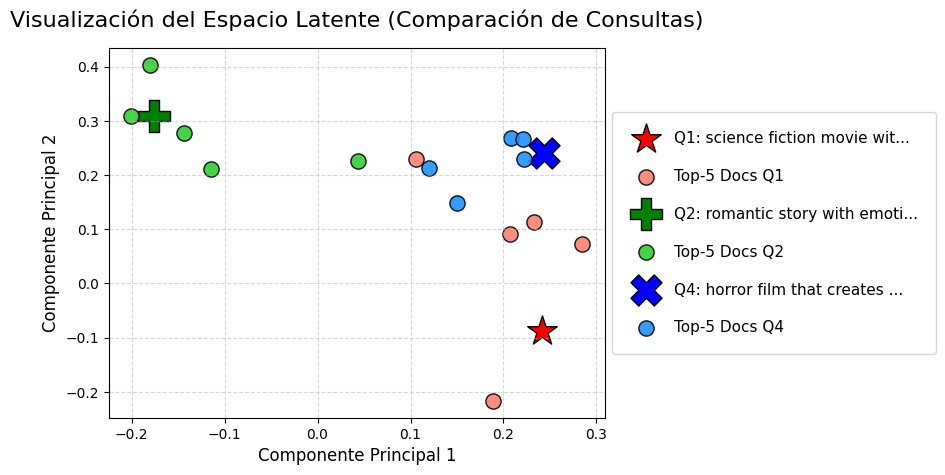

In [54]:
print("Aplicando PCA para visualizar el espacio semántico...")

# 1. Tomamos una muestra aleatoria del corpus para el fondo (1500 puntos para no saturar el gráfico)
np.random.seed(42) # Semilla para reproducibilidad
tamaño_muestra = 1500
indices_muestra = np.random.choice(len(document_embeddings), tamaño_muestra, replace=False)
embeddings_muestra = document_embeddings[indices_muestra]

# 2. Configuramos y entrenamos PCA para reducir de 384 a 2 dimensiones
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings_muestra) # Transformamos la muestra de fondo

# 3. Preparamos la Consulta 1 y sus resultados Top-5
consulta_ejemplo = queries[0] # "science fiction movie with advanced technology"
query_procesada = preprocess_text(consulta_ejemplo)
query_embedding = model.encode([query_procesada])

# 4. Definimos las consultas a visualizar y sus colores
# Elegimos Q1 (Ciencia Ficción), Q2 (Romance) y Q4 (Horror)
indices_a_graficar = [0, 1, 3] 
colores_query = ['red', 'green', 'blue']
colores_docs = ['salmon', 'limegreen', 'dodgerblue']
marcadores_query = ['*', 'P', 'X'] # Estrella, Cruz, X

# Iteramos sobre las consultas seleccionadas para graficarlas
for i, query_idx in enumerate(indices_a_graficar):
    consulta_texto = queries[query_idx]
    color_q = colores_query[i]
    color_d = colores_docs[i]
    marcador_q = marcadores_query[i]
    
    # Procesamos y transformamos la consulta
    query_procesada = preprocess_text(consulta_texto)
    query_embedding = model.encode([query_procesada])
    query_2d = pca.transform(query_embedding)
    
    # Obtenemos y transformamos los Top-5 de esta consulta
    top_5_ids = results[query_idx]['ID documento'].tolist()
    top_5_indices = df[df['Document ID'].isin(top_5_ids)].index.tolist()
    embeddings_top_5 = document_embeddings[top_5_indices]
    top_5_2d = pca.transform(embeddings_top_5)
    
    # Graficamos la consulta (marcador grande)
    plt.scatter(query_2d[:, 0], query_2d[:, 1], color=color_q, marker=marcador_q, s=500, 
                edgecolors='black', label=f'Q{query_idx+1}: {consulta_texto[:25]}...')
    
    # Graficamos los documentos Top-5 (círculos medianos)
    plt.scatter(top_5_2d[:, 0], top_5_2d[:, 1], color=color_d, s=120, 
                edgecolors='black', alpha=0.9, label=f'Top-5 Docs Q{query_idx+1}')

# Configuraciones estéticas
plt.title('Visualización del Espacio Latente (Comparación de Consultas)', fontsize=16, pad=15)
plt.xlabel('Componente Principal 1', fontsize=12)
plt.ylabel('Componente Principal 2', fontsize=12)

# Colocamos la leyenda fuera del gráfico para no tapar los puntos
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=11, labelspacing=1.5, handletextpad=0.8, borderpad=1.2)
plt.grid(True, linestyle='--', alpha=0.5)
#plt.tight_layout() 

plt.show()

### Conclusiones del Examen
1. **Calidad de los Embeddings:** Se comprobó que el preprocesamiento selectivo (mantener palabras clave eliminando ruido sintáctico) junto con un modelo Transformer especializado en oraciones, permite recuperar resultados altamente relevantes, superando las limitaciones de búsqueda exacta por palabras.
2. **Coherencia Semántica:** Como se evidencia en la visualización PCA, los resultados devueltos por similitud coseno se agrupan de manera lógica alrededor de la petición en el espacio vectorial, demostrando que el sistema realmente "entiende" el significado de la búsqueda y no solo cruza cadenas de texto.
3. **Escalabilidad y Muestreo:** Debido a la gran magnitud del corpus original (más de un millón de reseñas), el sistema se evaluó utilizando una muestra representativa aleatoria de 20,000 documentos para garantizar tiempos de ejecución viables en el entorno de desarrollo. La arquitectura del pipeline demuestra ser escalable, permitiendo su ejecución sobre el dataset completo en infraestructuras con mayor capacidad de cómputo.